## Outliers

- An outlier is a data point in a data set that is distant from all other observations, which is significantly from the remaining data.
- A data point that lies outside the overall distribution of the dataset.

#### What are the impacts of having outliers in a dataset?

1. It causes various problems during our statistical analysis (It may cause a significant impact on the mean and the standard deviation). Statistics such as the mean and variance are very susceptible to outliers.

2. In addition, **some Machine Learning models are sensitive to outliers** which may decrease their performance. Thus, depending on which algorithm we wish to train, we often remove outliers from our variables.



#### Reasons for Outliers

1. Data Entry Errors (Ex. Entering salary as 1,00,000 instead of 10,000)
2. Instrumental Errors
3. Instrumental Errors


#### Types of Outliers

1. Univeriate Outliers --> Indentifing outlier for single variable
2. Bivariate Outliers --> Indentifing as outlier by analyzing 2 variables at a time

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('claimants.csv')
df.head()

,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,ATTORNEY
0,5,0.0,1.0,0.0,50.0,34.940,0
1,3,1.0,0.0,0.0,18.0,0.891,1
2,66,0.0,1.0,0.0,5.0,0.330,1
3,70,0.0,1.0,1.0,31.0,0.037,0
4,96,0.0,1.0,0.0,30.0,0.038,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CASENUM   1340 non-null   int64  
 1   CLMSEX    1328 non-null   float64
 2   CLMINSUR  1299 non-null   float64
 3   SEATBELT  1292 non-null   float64
 4   CLMAGE    1151 non-null   float64
 5   LOSS      1340 non-null   float64
 6   ATTORNEY  1340 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 73.4 KB


In [4]:
df.isnull().sum()

CASENUM       0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
ATTORNEY      0
dtype: int64

In [5]:
df.LOSS.fillna(df.LOSS.median(), inplace=True)
df

C:\Users\abhay\AppData\Local\Temp\ipykernel_52356\3512891248.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.LOSS.fillna(df.LOSS.median(), inplace=True)


,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,ATTORNEY
0,5,0.0,1.0,0.0,50.0,34.940,0
1,3,1.0,0.0,0.0,18.0,0.891,1
2,66,0.0,1.0,0.0,5.0,0.330,1
3,70,0.0,1.0,1.0,31.0,0.037,0
4,96,0.0,1.0,0.0,30.0,0.038,1
...,...,...,...,...,...,...,...
1335,34100,0.0,1.0,0.0,NaN,0.576,1
1336,34110,1.0,1.0,0.0,46.0,3.705,0
1337,34113,1.0,1.0,0.0,39.0,0.099,1
1338,34145,1.0,0.0,0.0,8.0,3.177,0


##### **Various ways of finding the outlier.**

**Detectioin of outliers (based on Boxplot)**

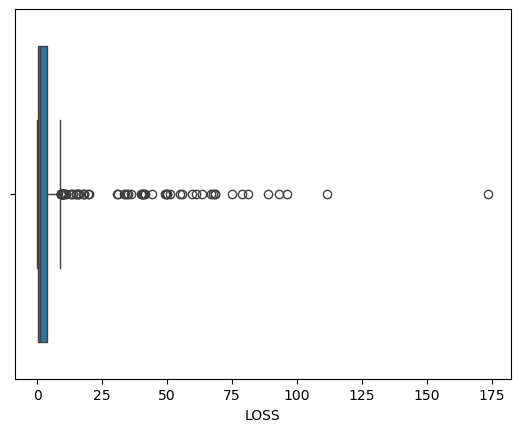

In [6]:
sns.boxplot(x = df.LOSS)
plt.show()

**Detection of outliers (based on IOR)**

- Calculate first(q1) and third quartile(q3)
- Find interquartile rand (q3-q1)
- Find lower bound q1 1.5 & Find upper bound q3 1.5

In [7]:
Q1 = df.LOSS.quantile(0.25)
Q1

np.float64(0.4)

In [8]:
Q3 = df.LOSS.quantile(0.75)
Q3

np.float64(3.7815)

In [9]:
IQR = Q3 - Q1
IQR

np.float64(3.3815)

In [10]:
lower_limit = Q1 - (IQR * 1.5)
upper_limit = Q3 + (IQR * 1.5)
lower_limit, upper_limit

(np.float64(-4.67225), np.float64(8.85375))

In [11]:
df[df.LOSS > 8.85]

,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,ATTORNEY
0,5,0.0,1.0,0.0,50.0,34.940,0
11,148,0.0,1.0,0.0,41.0,19.610,0
22,550,0.0,0.0,0.0,38.0,16.161,0
24,580,0.0,1.0,0.0,54.0,10.040,1
43,941,1.0,1.0,0.0,55.0,13.100,1
...,...,...,...,...,...,...,...
1179,30430,1.0,1.0,0.0,37.0,13.789,0
1188,30588,1.0,1.0,0.0,44.0,13.000,0
1256,31159,0.0,1.0,1.0,30.0,30.640,0
1286,33037,1.0,1.0,1.0,44.0,55.709,0


## Dealing the Outliers (3'R' Technique)

### 1. Remove (Trimming: remove the outliers from our dataset)

In [12]:
df_trimmed = df[(df.LOSS > lower_limit)& (df.LOSS < upper_limit)]
df_trimmed

,CASENUM,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS,ATTORNEY
1,3,1.0,0.0,0.0,18.0,0.891,1
2,66,0.0,1.0,0.0,5.0,0.330,1
3,70,0.0,1.0,1.0,31.0,0.037,0
4,96,0.0,1.0,0.0,30.0,0.038,1
5,97,1.0,1.0,0.0,35.0,0.309,0
...,...,...,...,...,...,...,...
1335,34100,0.0,1.0,0.0,NaN,0.576,1
1336,34110,1.0,1.0,0.0,46.0,3.705,0
1337,34113,1.0,1.0,0.0,39.0,0.099,1
1338,34145,1.0,0.0,0.0,8.0,3.177,0


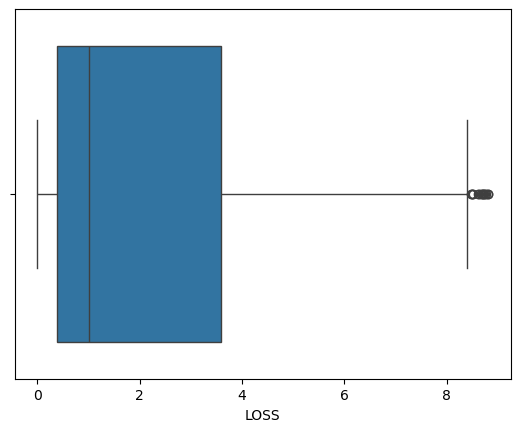

In [13]:
sns.boxplot(x = df_trimmed.LOSS)
plt.show()

- We can still see some outliers...
- When we remove data points from our dataset, all the parameters of the distribution are recalculated,
- Those are the mean, quantiles and inter-quantile range.
- Therefore, in the new- trimmed-variable, values that before were not considered outliers
- This is an unwanted characteristic of this way of coping with outliers.

#### 2. Replace the outliers

1. **Rectify or Replace --> (data entry error) --> Ask and confirm it from the Data Er. Team**

2. **Replace with upper limit & lower limit (calculated based on IQR)**

In [15]:
%pip install feature-engine

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [16]:
from feature_engine.outliers import Winsorizer
print("Feature-engine installed successfully!")

Feature-engine installed successfully!


In [20]:
from feature_engine.outliers import Winsorizer

win = Winsorizer(capping_method='iqr', tail = 'both',
                 fold = 1.5, variables=['LOSS'])

df_win = win.fit_transform(df[['LOSS']])
df_win


,LOSS
0,8.85375
1,0.89100
2,0.33000
3,0.03700
4,0.03800
...,...
1335,0.57600
1336,3.70500
1337,0.09900
1338,3.17700


In [21]:
print(win.left_tail_caps_, win.right_tail_caps_)

{'LOSS': -4.67225} {'LOSS': 8.85375}


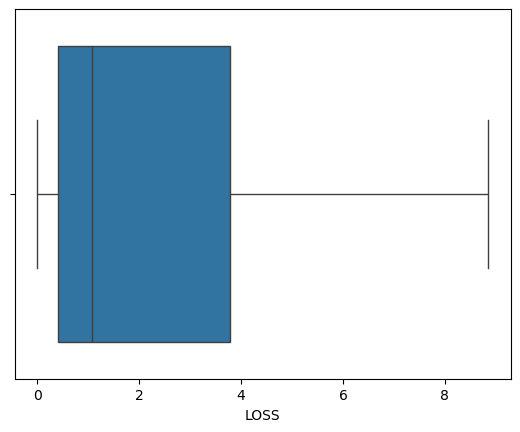

In [22]:
sns.boxplot(x = df_win.LOSS)
plt.show()


#### 3. Replace Arbitrary Outlier Capper (the minimmum and maximum values by a value determined by the user)

- we get the min and max values based on domain epertise

In [24]:
from feature_engine.outliers import ArbitraryOutlierCapper
capper = ArbitraryOutlierCapper(max_capping_dict={'LOSS':6},
                                min_capping_dict={'LOSS':0.03})

df_c = capper.fit_transform(df[['LOSS']])
df_c

,LOSS
0,6.000
1,0.891
2,0.330
3,0.037
4,0.038
...,...
1335,0.576
1336,3.705
1337,0.099
1338,3.177


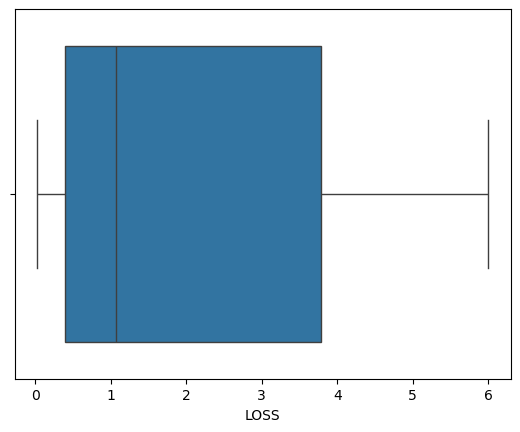

In [25]:
sns.boxplot(x = df_c.LOSS)
plt.show()